In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

df = pd.read_csv('../data/application_train.csv')
print(df.shape)
df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [2]:
missing_pct = df.isnull().sum() / len(df) * 100
cols_to_drop = missing_pct[missing_pct > 40].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >40% missing")
df.drop(columns=cols_to_drop, inplace=True)


df.drop(columns=['SK_ID_CURR'], inplace=True)

print("Shape after dropping:", df.shape)

Dropping 49 columns with >40% missing
Shape after dropping: (307511, 72)


In [3]:
df['AGE_YEARS'] = df['DAYS_BIRTH'] / -365


df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, 0)
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'] / -365
df['YEARS_EMPLOYED'] = df['YEARS_EMPLOYED'].clip(lower=0)

df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)

df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)

df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + 1)

df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)

print("New features created!")
print(df[['AGE_YEARS', 'YEARS_EMPLOYED', 'CREDIT_INCOME_RATIO', 
          'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 
          'INCOME_PER_PERSON']].head())

New features created!
   AGE_YEARS  YEARS_EMPLOYED  CREDIT_INCOME_RATIO  ANNUITY_INCOME_RATIO  \
0  25.920548        1.745205             2.007879              0.121977   
1  45.931507        3.254795             4.790732              0.132216   
2  52.180822        0.616438             1.999970              0.099999   
3  52.068493        8.326027             2.316150              0.219898   
4  54.608219        8.323288             4.222187              0.179961   

   CREDIT_GOODS_RATIO  INCOME_PER_PERSON  
0            1.158394           101250.0  
1            1.145198            90000.0  
2            0.999993            33750.0  
3            1.052799            45000.0  
4            0.999998            60750.0  


In [4]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

print(f"Total features: {X.shape[1]}")
print(f"Categorical: {len(categorical_cols)}")
print(f"Numerical: {len(numerical_cols)}")
print(f"\nDefault rate: {y.mean():.3f}")

Total features: 77
Categorical: 12
Numerical: 65

Default rate: 0.081


In [5]:
cols_to_remove = ['DAYS_BIRTH', 'DAYS_EMPLOYED']
df.drop(columns=cols_to_remove, inplace=True)

X = df.drop('TARGET', axis=1)
y = df['TARGET']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Final feature count:", X.shape[1])
print("Categorical:", len(categorical_cols))
print("Numerical:", len(numerical_cols))

Final feature count: 75
Categorical: 12
Numerical: 63


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Default rate in train:", y_train.mean().round(3))
print("Default rate in test:", y_test.mean().round(3))

Train size: (246008, 75)
Test size: (61503, 75)
Default rate in train: 0.081
Default rate in test: 0.081


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print("Preprocessing pipeline ready!")

Preprocessing pipeline ready!


In [8]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, 
        class_weight='balanced', n_jobs=-1,
        min_samples_leaf=5), 
    
    'XGBoost': XGBClassifier(
        n_estimators=150, random_state=42,
        scale_pos_weight=11, 
        max_depth=6,         
        learning_rate=0.1,   
        eval_metric='logloss', verbosity=0),
    
    'LightGBM': LGBMClassifier(
        n_estimators=150, random_state=42,
        scale_pos_weight=11, 
        max_depth=6, 
        learning_rate=0.1, 
        verbose=-1)
}

results = {}

for name, model in models.items():
    print(f"=Training {name}=")
    
    
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    results[name] = {'f1': f1, 'roc_auc': roc, 'pipeline': pipe}
    
   
    print(classification_report(y_test, y_pred, target_names=['Not Default', 'Default']))
    print(f"ROC-AUC Score: {roc:.3f}")
    print("\n" + "-"*40 + "\n")

=Training Logistic Regression=
              precision    recall  f1-score   support

 Not Default       0.96      0.69      0.80     56538
     Default       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503

ROC-AUC Score: 0.746

----------------------------------------

=Training Random Forest=
              precision    recall  f1-score   support

 Not Default       0.94      0.92      0.93     56538
     Default       0.26      0.31      0.29      4965

    accuracy                           0.87     61503
   macro avg       0.60      0.62      0.61     61503
weighted avg       0.88      0.87      0.88     61503

ROC-AUC Score: 0.747

----------------------------------------

=Training XGBoost=
              precision    recall  f1-score   support

 Not Default       0.96      0.73      0.83     56538
     Default       0.17      0.64 

In [9]:
for name, result in results.items():
    pipe = result['pipeline']
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    print(f"{name}:")
    print(f"  Predicted defaults: {y_pred.sum()} out of {len(y_pred)}")
    print(f"  Actual defaults: {y_test.sum()}")
    print(f"  Avg fraud probability: {y_prob.mean():.3f}")
    print()

Logistic Regression:
  Predicted defaults: 20883 out of 61503
  Actual defaults: 4965
  Avg fraud probability: 0.423

Random Forest:
  Predicted defaults: 5954 out of 61503
  Actual defaults: 4965
  Avg fraud probability: 0.295

XGBoost:
  Predicted defaults: 18202 out of 61503
  Actual defaults: 4965
  Avg fraud probability: 0.390

LightGBM:
  Predicted defaults: 18939 out of 61503
  Actual defaults: 4965
  Avg fraud probability: 0.395



In [10]:
from sklearn.model_selection import GridSearchCV

tuning_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        random_state=42,
        scale_pos_weight=11,
        verbose=-1))
])

param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.05, 0.1],
    'model__num_leaves': [31, 50],
}

grid_search = GridSearchCV(
    tuning_pipe,
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 3))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 8, 'model__n_estimators': 200, 'model__num_leaves': 31}
Best CV ROC-AUC: 0.75


Tuned LightGBM → F1: 0.270 | ROC-AUC: 0.757

Classification Report:
              precision    recall  f1-score   support

 Not Default       0.96      0.71      0.82     56538
     Default       0.17      0.67      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.54     61503
weighted avg       0.90      0.71      0.77     61503



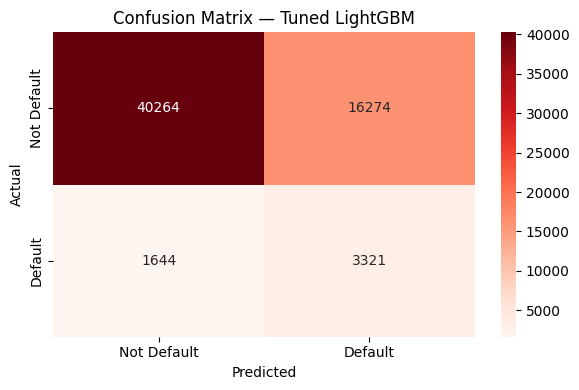

In [11]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

f1_tuned = f1_score(y_test, y_pred_tuned)
roc_tuned = roc_auc_score(y_test, y_prob_tuned)

print(f"Tuned LightGBM → F1: {f1_tuned:.3f} | ROC-AUC: {roc_tuned:.3f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned, 
      target_names=['Not Default', 'Default']))

from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Default', 'Default'],
            yticklabels=['Not Default', 'Default'])
plt.title('Confusion Matrix — Tuned LightGBM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [12]:
import shap

lgbm_model = best_model.named_steps['model']
preprocessor_fitted = best_model.named_steps['preprocessor']

X_test_transformed = preprocessor_fitted.transform(X_test)

ohe_features = best_model.named_steps['preprocessor']\
    .named_transformers_['cat']['encoder']\
    .get_feature_names_out(categorical_cols).tolist()
all_features = numerical_cols + ohe_features

explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_transformed)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("SHAP values computed!")
print("Shape:", shap_values.shape)

SHAP values computed!
Shape: (61503, 187)


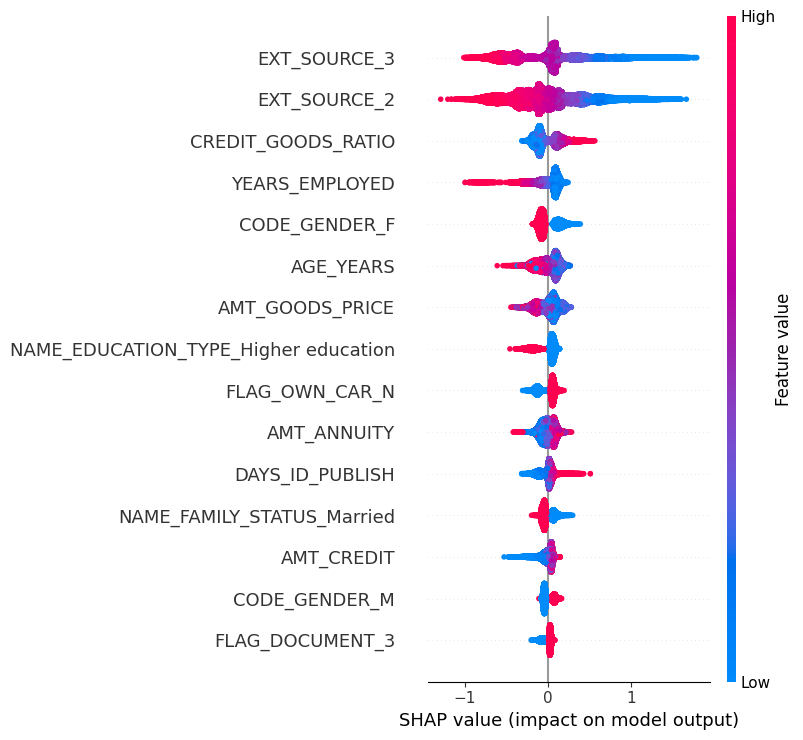

In [13]:
plt.figure()
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_features,
                  max_display=15)

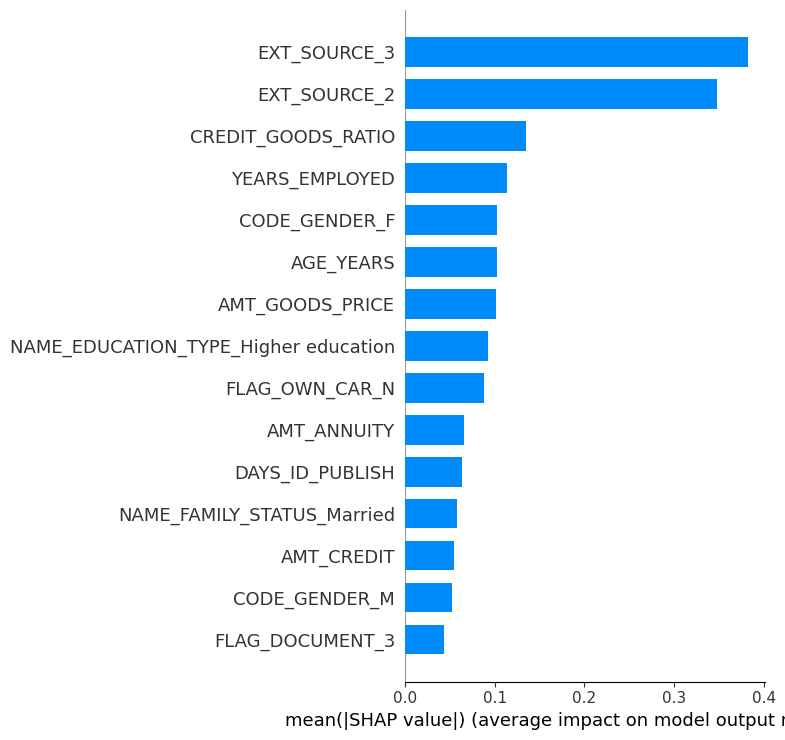

In [14]:
plt.figure()
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=all_features,
                  plot_type='bar',
                  max_display=15)

In [15]:
import joblib
import os

os.makedirs('../models', exist_ok=True)


joblib.dump(best_model, '../models/loan_default_model.pkl')
joblib.dump(categorical_cols, '../models/categorical_cols.pkl')
joblib.dump(numerical_cols, '../models/numerical_cols.pkl')

print("Model saved!")
print(os.listdir('../models'))

Model saved!
['categorical_cols.pkl', 'loan_default_model.pkl', 'numerical_cols.pkl']


In [3]:
bureau = pd.read_csv('../data/bureau.csv')
print("Shape:", bureau.shape)
print("\nUnique applicants (SK_ID_CURR):", bureau['SK_ID_CURR'].nunique())
print("Total rows:", len(bureau))
print("\nColumns:")
print(bureau.columns.tolist())
bureau.head()

Shape: (1716428, 17)

Unique applicants (SK_ID_CURR): 305811
Total rows: 1716428

Columns:
['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [ ]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT=('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE_LOANS=('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CREDIT_TYPES=('CREDIT_TYPE', 'nunique'),
    BUREAU_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    BUREAU_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),
    BUREAU_MAX_OVERDUE_DAYS=('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_MAX_AMT_OVERDUE=('AMT_CREDIT_MAX_OVERDUE', 'max'),
    BUREAU_TOTAL_PROLONG=('CNT_CREDIT_PROLONG', 'sum'),
    BUREAU_TOTAL_CREDIT_SUM=('AMT_CREDIT_SUM', 'sum'),
    BUREAU_TOTAL_DEBT=('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_TOTAL_OVERDUE=('AMT_CREDIT_SUM_OVERDUE', 'sum'),
).reset_index()


bureau_agg['BUREAU_DEBT_CREDIT_RATIO'] = (
    bureau_agg['BUREAU_TOTAL_DEBT'] / (bureau_agg['BUREAU_TOTAL_CREDIT_SUM'] + 1)
)

print("Aggregated shape:", bureau_agg.shape)
print("\nMissing values:")
print(bureau_agg.isnull().sum())
bureau_agg.head()

Aggregated shape: (305811, 13)

Missing values:
SK_ID_CURR                      0
BUREAU_LOAN_COUNT               0
BUREAU_ACTIVE_LOANS             0
BUREAU_CREDIT_TYPES             0
BUREAU_DAYS_CREDIT_MEAN         0
BUREAU_DAYS_CREDIT_MIN          0
BUREAU_MAX_OVERDUE_DAYS         0
BUREAU_MAX_AMT_OVERDUE      92840
BUREAU_TOTAL_PROLONG            0
BUREAU_TOTAL_CREDIT_SUM         0
BUREAU_TOTAL_DEBT               0
BUREAU_TOTAL_OVERDUE            0
BUREAU_DEBT_CREDIT_RATIO        0
dtype: int64


,SK_ID_CURR,BUREAU_LOAN_COUNT,BUREAU_ACTIVE_LOANS,BUREAU_CREDIT_TYPES,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MIN,BUREAU_MAX_OVERDUE_DAYS,BUREAU_MAX_AMT_OVERDUE,BUREAU_TOTAL_PROLONG,BUREAU_TOTAL_CREDIT_SUM,BUREAU_TOTAL_DEBT,BUREAU_TOTAL_OVERDUE,BUREAU_DEBT_CREDIT_RATIO
0,100001,7,3,1,-735.000000,-1572,0,NaN,0,1453365.000,596686.5,0.0,0.410555
1,100002,8,2,2,-874.000000,-1437,0,5043.645,0,865055.565,245781.0,0.0,0.284121
2,100003,4,1,2,-1400.750000,-2586,0,0.000,0,1017400.500,0.0,0.0,0.000000
3,100004,2,0,1,-867.000000,-1326,0,0.000,0,189037.800,0.0,0.0,0.000000
4,100005,3,2,2,-190.666667,-373,0,0.000,0,657126.000,568408.5,0.0,0.864990


In [5]:
bureau_agg['BUREAU_MAX_AMT_OVERDUE'] = bureau_agg['BUREAU_MAX_AMT_OVERDUE'].fillna(0)
print("Missing after fill:", bureau_agg['BUREAU_MAX_AMT_OVERDUE'].isnull().sum())

Missing after fill: 0
